
Processing sst
Found 816 files
sst: 1/816
sst: 50/816
sst: 100/816
sst: 150/816
sst: 200/816
sst: 250/816
sst: 300/816
sst: 350/816
sst: 400/816
sst: 450/816
sst: 500/816
sst: 550/816
sst: 600/816
sst: 650/816
sst: 700/816
sst: 750/816
sst: 800/816
sst: 816/816


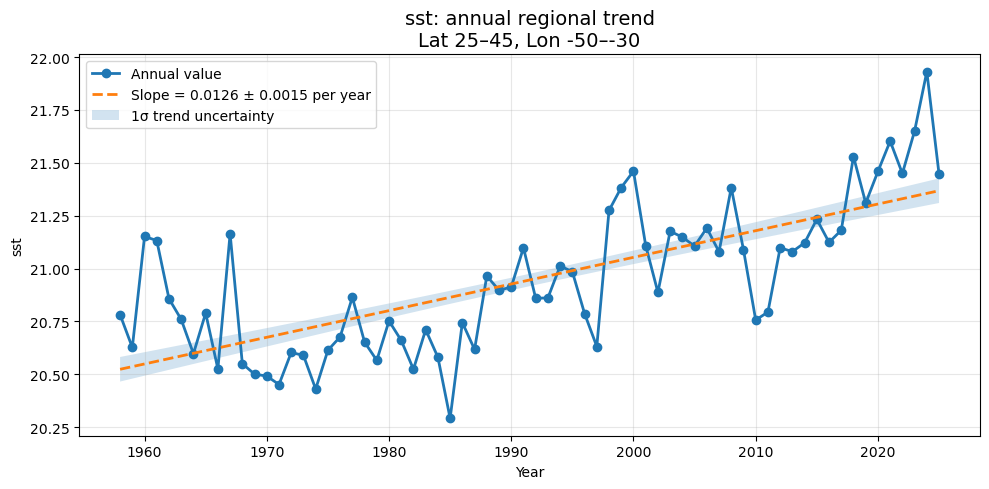

Slope   = 0.012602 ± 0.00149638 per year
R²      = 0.5180

Processing salinity
Found 791 files
salinity: 1/791
salinity: 50/791
salinity: 100/791
salinity: 150/791
salinity: 200/791
salinity: 250/791
salinity: 300/791
salinity: 350/791
salinity: 400/791
salinity: 450/791
salinity: 500/791
salinity: 550/791
salinity: 600/791
salinity: 650/791
salinity: 700/791
salinity: 750/791
salinity: 791/791


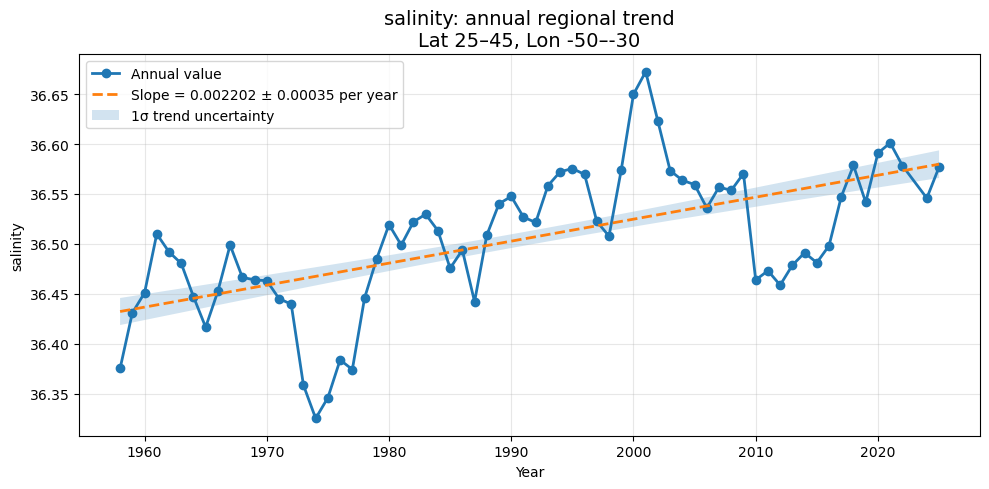

Slope   = 0.00220248 ± 0.00035388 per year
R²      = 0.3734

Processing thetao
Found 785 files
thetao: 1/785
thetao: 50/785
thetao: 100/785
thetao: 150/785
thetao: 200/785
thetao: 250/785
thetao: 300/785
thetao: 350/785
thetao: 400/785
thetao: 450/785
thetao: 500/785
thetao: 550/785
thetao: 600/785
thetao: 650/785
thetao: 700/785
thetao: 750/785
thetao: 785/785


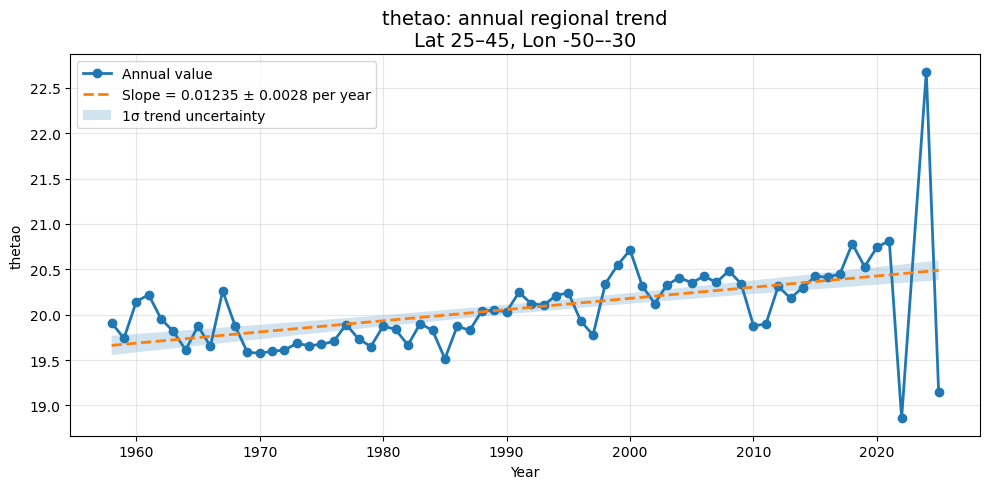

Slope   = 0.0123455 ± 0.00277689 per year
R²      = 0.2332

Processing qnet
Found 791 files
qnet: 1/791
qnet: 50/791
qnet: 100/791
qnet: 150/791
qnet: 200/791
qnet: 250/791
qnet: 300/791
qnet: 350/791
qnet: 400/791
qnet: 450/791
qnet: 500/791
qnet: 550/791
qnet: 600/791
qnet: 650/791
qnet: 700/791
qnet: 750/791
qnet: 791/791


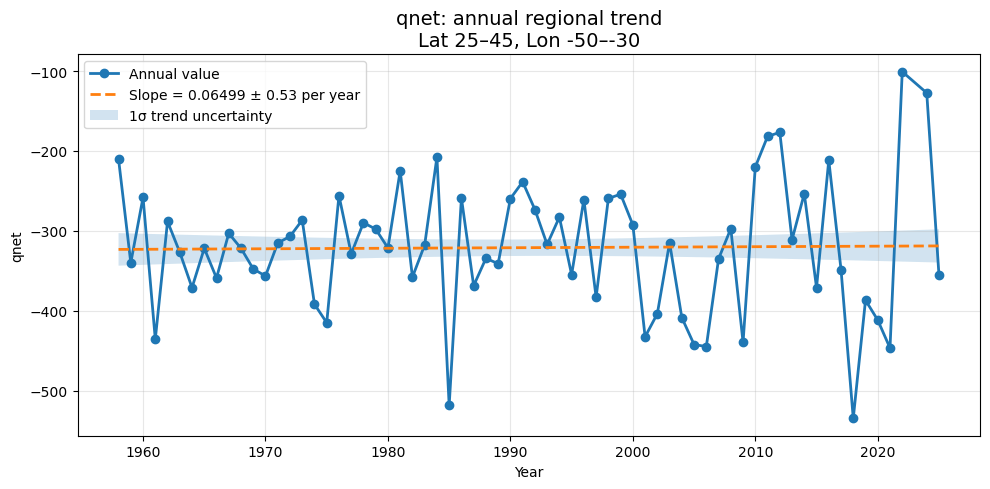

Slope   = 0.0649944 ± 0.531168 per year
R²      = 0.0002

Processing u_current
Found 793 files
u_current: 1/793
u_current: 50/793
u_current: 100/793
u_current: 150/793
u_current: 200/793
u_current: 250/793
u_current: 300/793
u_current: 350/793
u_current: 400/793
u_current: 450/793
u_current: 500/793
u_current: 550/793
u_current: 600/793
u_current: 650/793
u_current: 700/793
u_current: 750/793
u_current: 793/793


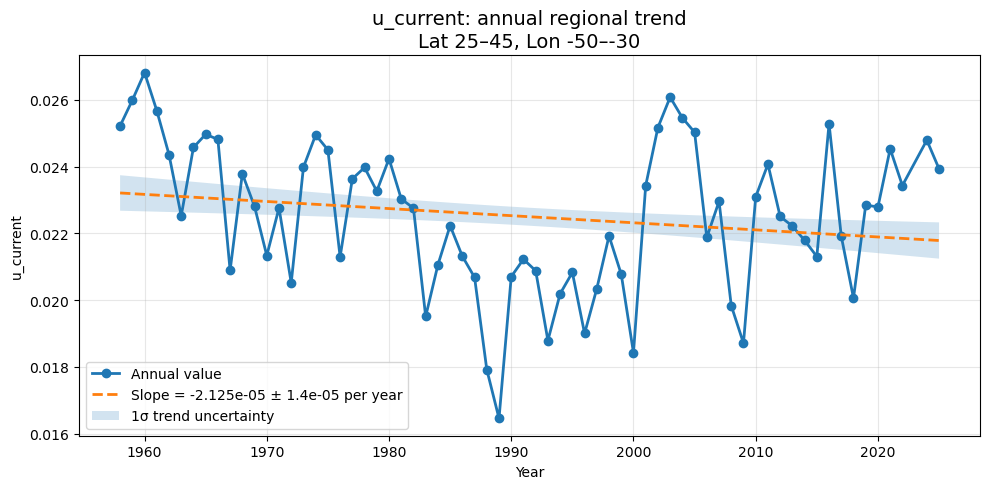

Slope   = -2.12497e-05 ± 1.388e-05 per year
R²      = 0.0348

Processing v_current
Found 794 files
v_current: 1/794
v_current: 50/794
v_current: 100/794
v_current: 150/794
v_current: 200/794
v_current: 250/794
Skipping ORAS5_1979_02_v_meridional_boxed.nc: Could not find coordinate from ['latitude', 'lat', 'nav_lat']
v_current: 300/794
v_current: 350/794
v_current: 400/794
v_current: 450/794
v_current: 500/794
v_current: 550/794
v_current: 600/794
v_current: 650/794
v_current: 700/794
v_current: 750/794
v_current: 794/794


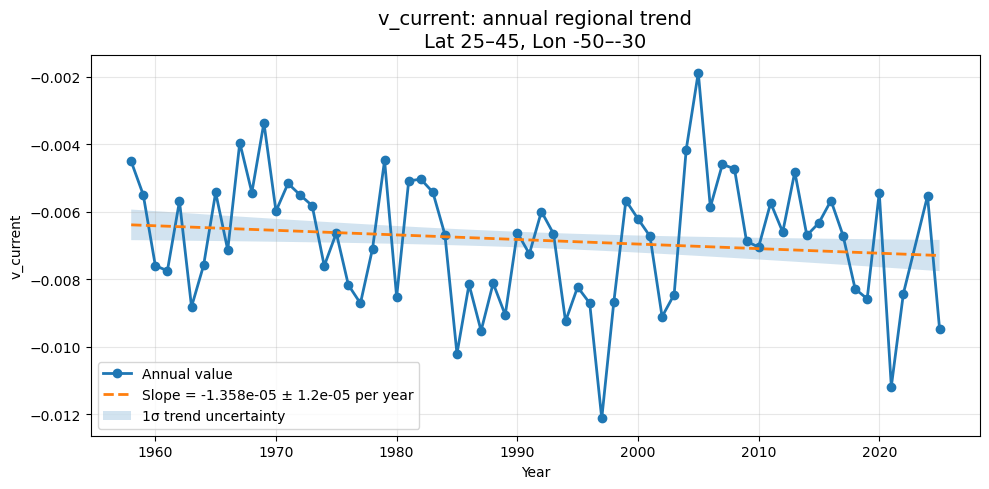

Slope   = -1.35754e-05 ± 1.18561e-05 per year
R²      = 0.0198


In [7]:
import re
from pathlib import Path

import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

DATA_DIR = Path(r"C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\ORAS5\BOXED")

LAT_MIN, LAT_MAX = 25, 45
LON_MIN, LON_MAX = -50, -30

FILE_RE = re.compile(r"ORAS5_(\d{4})_(\d{2})_(.+?)_boxed\.nc$")

VAR_META = {
    "sst": {
        "token": "sst",
        "agg": "mean",
        "depth_mode": None,
    },
    "salinity": {
        "token": "so_salinity",
        "agg": "mean",
        "depth_mode": "0_100m",
    },
    "thetao": {
        "token": "thetao_potential_temperature",
        "agg": "mean",
        "depth_mode": "0_100m",
    },
    "qnet": {
        "token": "net_downward_heat_flux",
        "agg": "sum",
        "depth_mode": None,
    },
    "u_current": {
        "token": "u_zonal",
        "agg": "mean",
        "depth_mode": "0_100m",
    },
    "v_current": {
        "token": "v_meridional",
        "agg": "mean",
        "depth_mode": "0_100m",
    },
}

def files_for_token(data_dir, token):
    matched_files = []

    for p in sorted(data_dir.glob("ORAS5_*_*_*_boxed.nc")):

        m = FILE_RE.match(p.name)

        if m is None:
            continue

        year = int(m.group(1))
        month = int(m.group(2))
        file_token = m.group(3)

        if token in file_token:
            matched_files.append((year, month, p))

    return matched_files


def get_coord_name(ds, possible_names):
    for name in possible_names:
        if name in ds.coords or name in ds.dims:
            return name

    raise ValueError(f"Could not find coordinate from {possible_names}")


def get_data_var(ds):
    data_vars = list(ds.data_vars)

    numeric_vars = [
        v for v in data_vars
        if np.issubdtype(ds[v].dtype, np.number)
    ]

    if len(numeric_vars) == 0:
        raise ValueError(f"No numeric data variable found. Found: {data_vars}")

    return numeric_vars[0]


def depth_average_if_needed(da, depth_mode):

    if depth_mode is None:
        return da

    depth_candidates = [
        "depth",
        "deptht",
        "lev",
        "olevel",
        "z",
        "depthu",
        "depthv",
    ]

    depth_name = None

    for name in depth_candidates:
        if name in da.coords or name in da.dims:
            depth_name = name
            break

    if depth_name is None:
        return da

    if depth_mode == "0_100m":
        da = da.sel({depth_name: slice(0, 100)})
        da = da.mean(depth_name, skipna=True)

    return da


def regional_mean_single_file(path, depth_mode):

    with xr.open_dataset(path) as ds:

        lat_name = get_coord_name(ds, ["latitude", "lat", "nav_lat"])
        lon_name = get_coord_name(ds, ["longitude", "lon", "nav_lon"])

        data_var = get_data_var(ds)

        da = ds[data_var]

        da = depth_average_if_needed(da, depth_mode)

        lat = da[lat_name]
        lon = da[lon_name]

        lon_fixed = xr.where(lon > 180, lon - 360, lon)

        mask = (
            (lat >= LAT_MIN) &
            (lat <= LAT_MAX) &
            (lon_fixed >= LON_MIN) &
            (lon_fixed <= LON_MAX)
        )

        da_box = da.where(mask)

        weights = np.cos(np.deg2rad(lat))

        spatial_dims = lat.dims

        weighted_sum = (da_box * weights).sum(
            dim=spatial_dims,
            skipna=True
        )

        weight_sum = weights.where(np.isfinite(da_box)).sum(
            dim=spatial_dims,
            skipna=True
        )

        regional_mean = weighted_sum / weight_sum

        value = float(regional_mean.squeeze().values)

    return value

annual_results = {}

for var_name, meta in VAR_META.items():

    print(f"\nProcessing {var_name}")

    files = files_for_token(DATA_DIR, meta["token"])

    print(f"Found {len(files)} files")

    if len(files) == 0:
        print(f"Skipping {var_name}: no files found.")
        continue

    monthly_values = []

    for i, (year, month, path) in enumerate(files, start=1):

        if i == 1 or i % 50 == 0 or i == len(files):
            print(f"{var_name}: {i}/{len(files)}")

        try:
            value = regional_mean_single_file(
                path,
                meta["depth_mode"]
            )

            monthly_values.append({
                "year": year,
                "month": month,
                "value": value
            })

        except Exception as e:
            print(f"Skipping {path.name}: {e}")

    monthly_df = pd.DataFrame(monthly_values)

    monthly_df = monthly_df.sort_values(["year", "month"])

    if meta["agg"] == "sum":
        annual_df = monthly_df.groupby("year", as_index=False)["value"].sum()
    else:
        annual_df = monthly_df.groupby("year", as_index=False)["value"].mean()

    annual_results[var_name] = annual_df

    x = annual_df["year"].values
    y = annual_df["value"].values

    slope, intercept, r_value, p_value, slope_err = stats.linregress(x, y)

    trend = intercept + slope * x

    residuals = y - trend
    n = len(y)

    sigma_resid = np.sqrt(np.sum(residuals**2) / (n - 2))

    x_mean = np.mean(x)
    Sxx = np.sum((x - x_mean)**2)

    trend_sigma = sigma_resid * np.sqrt(
        1 / n + ((x - x_mean)**2 / Sxx)
    )

    upper_band = trend + trend_sigma
    lower_band = trend - trend_sigma

    plt.figure(figsize=(10, 5))

    plt.plot(
        x,
        y,
        marker="o",
        linewidth=2,
        label="Annual value"
    )

    plt.plot(
        x,
        trend,
        linestyle="--",
        linewidth=2,
        label=f"Slope = {slope:.4g} ± {slope_err:.2g} per year"
    )

    plt.fill_between(
        x,
        lower_band,
        upper_band,
        alpha=0.2,
        label="1σ trend uncertainty"
    )

    plt.title(
        f"{var_name}: annual regional trend\n"
        f"Lat {LAT_MIN}–{LAT_MAX}, Lon {LON_MIN}–{LON_MAX}",
        fontsize=14
    )

    plt.xlabel("Year")
    plt.ylabel(var_name)

    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(f"Slope   = {slope:.6g} ± {slope_err:.6g} per year")
    print(f"R²      = {r_value**2:.4f}")